# CS4641 Team 118 - House Price Prediction Midterm Checkpoint
# Southern California Housing Market Analysis


In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Setting visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. DATA LOADING AND INITIAL EXPLORATION

In [2]:
# Load the dataset
df = pd.read_csv('../../data/socal2_7_columns.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (15474, 7)
Number of rows: 15474
Number of columns: 7

First 5 Rows
   image_id                 street             citi  bed  bath  sqft   price
0         0  1317 Van Buren Avenue  Salton City, CA    3   2.0  1560  201900
1         1         124 C Street W      Brawley, CA    3   2.0   713  228500
2         2        2304 Clark Road     Imperial, CA    3   1.0   800  273950
3         3     755 Brawley Avenue      Brawley, CA    3   1.0  1082  350000
4         4  2207 R Carrillo Court     Calexico, CA    4   3.0  2547  385100

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15474 entries, 0 to 15473
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   image_id  15474 non-null  int64  
 1   street    15474 non-null  object 
 2   citi      15474 non-null  object 
 3   bed       15474 non-null  int64  
 4   bath      15474 non-null  float64
 5   sqft      15474 non-null  int64  
 6   price     1547

# 2. EXPLORATORY DATA ANALYSIS (EDA)

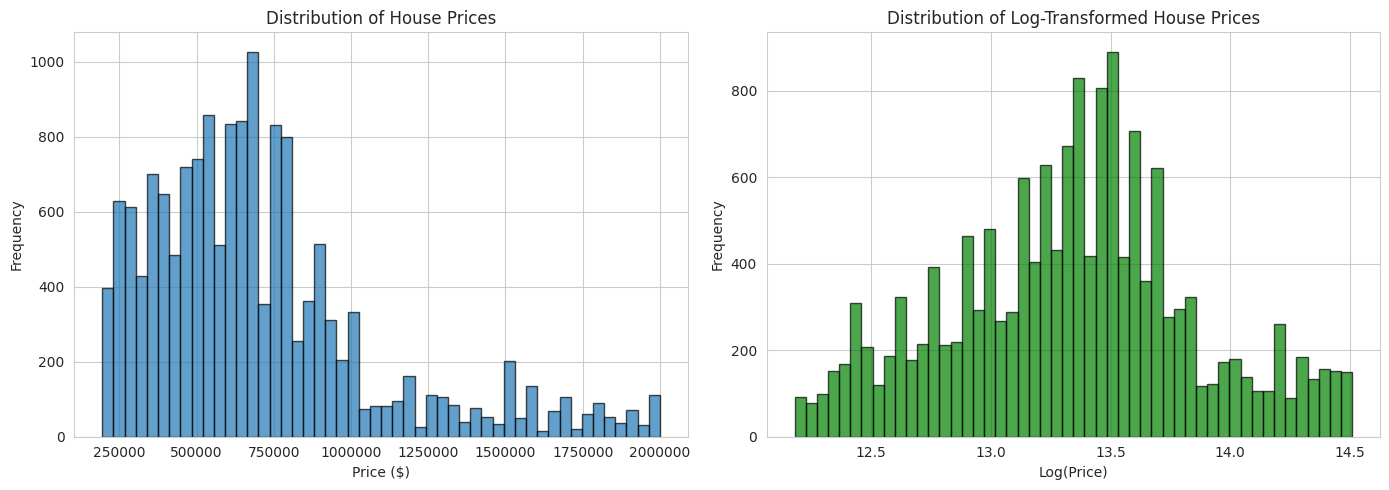


Price Statistics:
Mean Price: $703,120.94
Median Price: $639,000.00
Min Price: $195,000.00
Max Price: $2,000,000.00
Std Dev: $376,976.15

 Top 10 Cities by Number of Properties:
citi
San Diego, CA       707
Los Angeles, CA     388
Lancaster, CA       312
La Quinta, CA       305
Riverside, CA       274
Corona, CA          257
Escondido, CA       242
Fontana, CA         230
Palm Springs, CA    228
Big Bear, CA        228
Name: count, dtype: int64


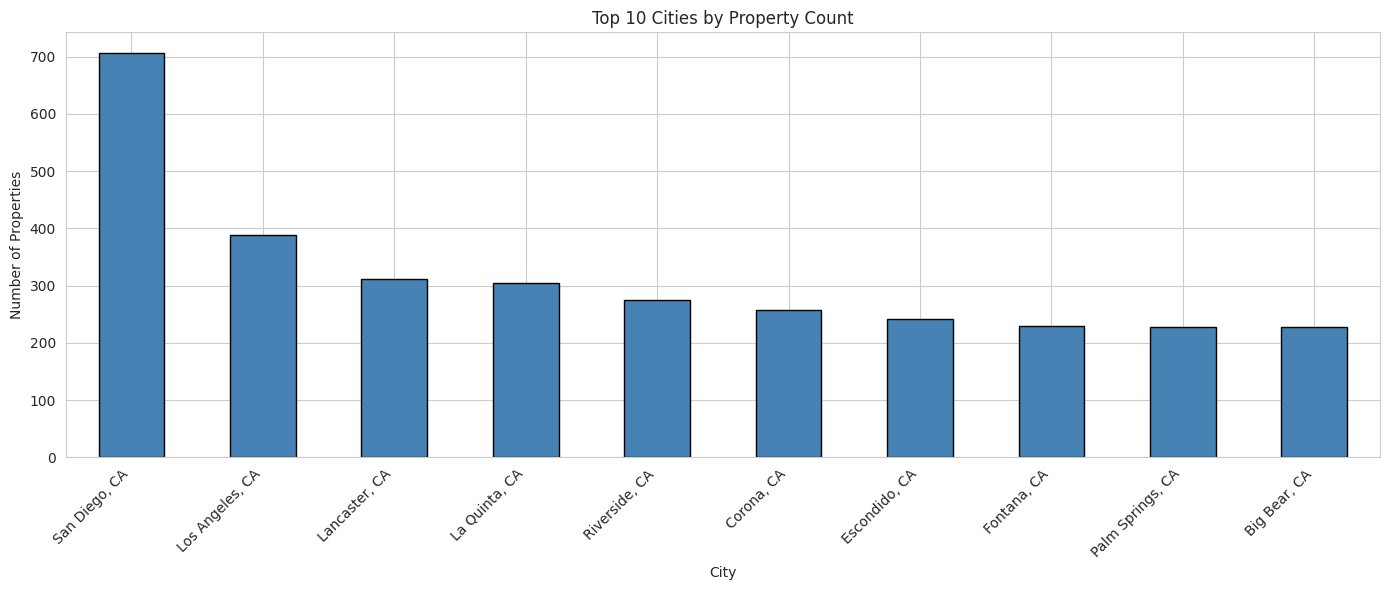

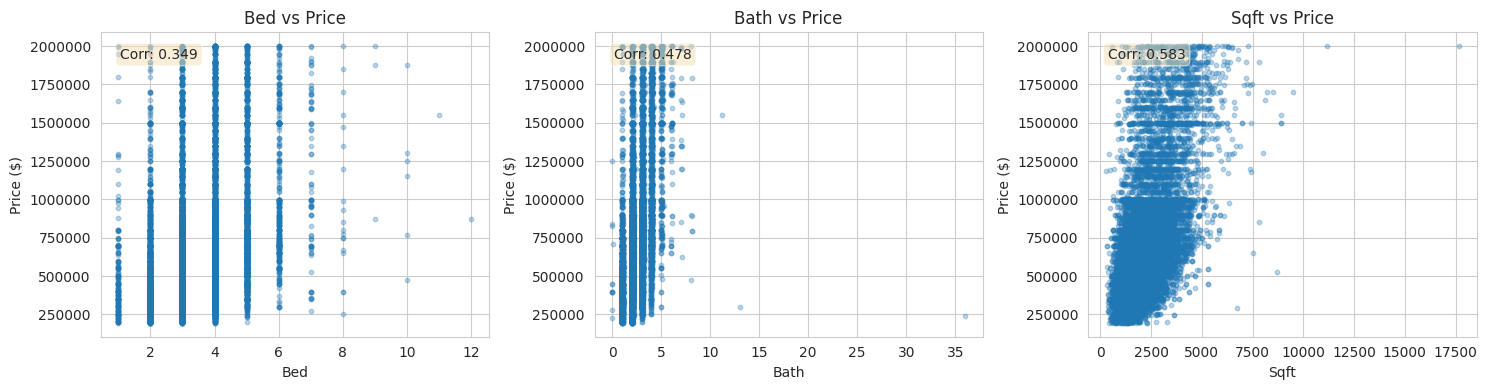

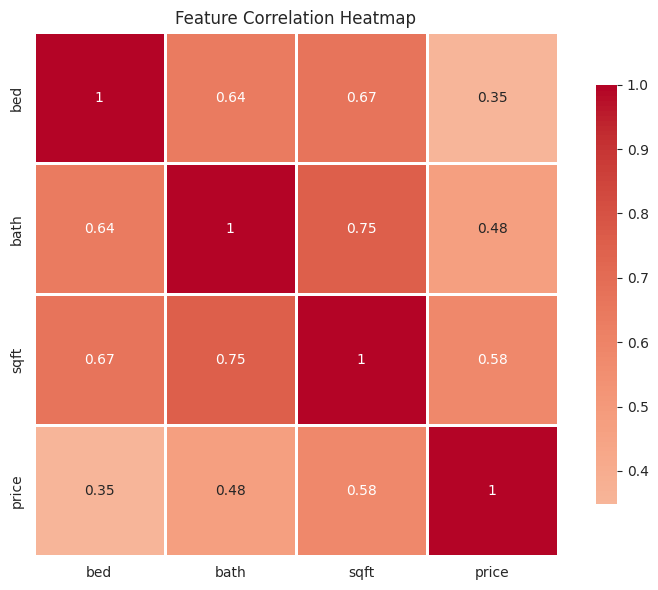


 Correlation with Price:
price    1.000000
sqft     0.583457
bath     0.477735
bed      0.348711
Name: price, dtype: float64


In [3]:
# Distribution of target variable (price)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.ticklabel_format(style='plain', axis='x')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.title('Distribution of Log-Transformed House Prices')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPrice Statistics:")
print(f"Mean Price: ${df['price'].mean():,.2f}")
print(f"Median Price: ${df['price'].median():,.2f}")
print(f"Min Price: ${df['price'].min():,.2f}")
print(f"Max Price: ${df['price'].max():,.2f}")
print(f"Std Dev: ${df['price'].std():,.2f}")

# City distribution
print(f"\n Top 10 Cities by Number of Properties:")
city_counts = df['citi'].value_counts().head(10)
print(city_counts)

plt.figure(figsize=(14, 6))
city_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('City')
plt.ylabel('Number of Properties')
plt.title('Top 10 Cities by Property Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('city_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Numeric features correlation with price
numeric_features = ['bed', 'bath', 'sqft']

plt.figure(figsize=(15, 4))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df[feature], df['price'], alpha=0.3, s=10)
    plt.xlabel(feature.capitalize())
    plt.ylabel('Price ($)')
    plt.title(f'{feature.capitalize()} vs Price')
    plt.ticklabel_format(style='plain', axis='y')

    # Adding correlation coefficient
    corr = df[[feature, 'price']].corr().iloc[0, 1]
    plt.text(0.05, 0.95, f'Corr: {corr:.3f}',
             transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             verticalalignment='top')

plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_features + ['price']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Correlation with Price:")
print(correlation_matrix['price'].sort_values(ascending=False))

# 3. DATA PREPROCESSING

In [4]:
# Creating a copy for preprocessing
df_processed = df.copy()

# 3.1 Handling any missing values

In [5]:
print(f"Missing values before imputation:")
print(df_processed.isnull().sum())

# Impute numeric columns with median
numeric_cols = ['bed', 'bath', 'sqft', 'price']
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        imputer = SimpleImputer(strategy='median')
        df_processed[col] = imputer.fit_transform(df_processed[[col]])
        print(f"Imputed {col} with median")

# Impute categorical columns with most frequent
categorical_cols = ['citi', 'street']
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        imputer = SimpleImputer(strategy='most_frequent')
        df_processed[col] = imputer.fit_transform(df_processed[[col]]).ravel()
        print(f"Imputed {col} with most frequent value")

print(f"\nMissing values after imputation:")
print(df_processed.isnull().sum())

Missing values before imputation:
image_id    0
street      0
citi        0
bed         0
bath        0
sqft        0
price       0
dtype: int64

Missing values after imputation:
image_id    0
street      0
citi        0
bed         0
bath        0
sqft        0
price       0
dtype: int64


# 3.2 Feature Engineering

In [6]:
# Price per square foot
df_processed['price_per_sqft'] = df_processed['price'] / df_processed['sqft']
print("Created: price_per_sqft")

# Square feet per room (bedroom)
df_processed['sqft_per_room'] = df_processed['sqft'] / df_processed['bed'].replace(0, 1)
print("Created: sqft_per_room")

# Total rooms
df_processed['total_rooms'] = df_processed['bed'] + df_processed['bath']
print("Created: total_rooms")

# Bath to bed ratio
df_processed['bath_to_bed_ratio'] = df_processed['bath'] / df_processed['bed'].replace(0, 1)
print("Created: bath_to_bed_ratio")

print("\nNew features created:")
new_features = ['price_per_sqft', 'sqft_per_room', 'total_rooms', 'bath_to_bed_ratio']
print(df_processed[new_features].describe())

Created: price_per_sqft
Created: sqft_per_room
Created: total_rooms
Created: bath_to_bed_ratio

New features created:
       price_per_sqft  sqft_per_room   total_rooms  bath_to_bed_ratio
count    15474.000000   15474.000000  15474.000000       15474.000000
mean       349.909523     617.301039      5.959648           0.711805
std        182.584081     212.657219      1.804292           0.216684
min         43.130519      93.333333      2.000000           0.000000
25%        229.593702     467.666667      5.000000           0.525000
50%        314.908009     578.666667      6.000000           0.666667
75%        422.544458     722.800000      7.000000           0.775000
max       4228.571429    3375.000000     40.000000           9.000000


# 3.3 Handling any outliers

In [7]:
# Identifying outliers using IQR method for price
Q1 = df_processed['price'].quantile(0.25)
Q3 = df_processed['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df_processed['price'] < lower_bound) | (df_processed['price'] > upper_bound)
n_outliers = outliers_mask.sum()

print(f"Number of price outliers detected (IQR method): {n_outliers}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

# For robustness, we'll keep the outliers but note their impact
# Alternatively, we could remove them with: df_processed = df_processed[~outliers_mask]

Number of price outliers detected (IQR method): 1136
Lower bound: $-139,962.50
Upper bound: $1,419,937.50


# 3.4 Categorical/Label Encoding for City

In [8]:
label_encoder = LabelEncoder()
df_processed['citi_encoded'] = label_encoder.fit_transform(df_processed['citi'])

print(f"Number of unique cities: {df_processed['citi'].nunique()}")
print(f"\nSample city encoding:")
city_encoding_sample = df_processed[['citi', 'citi_encoded']].drop_duplicates().head(10)
print(city_encoding_sample)

# Save the processed dataset
df_processed.to_csv('socal_processed.csv', index=False)
print("\nProcessed dataset saved as 'socal_processed.csv'")

Number of unique cities: 415

Sample city encoding:
                citi  citi_encoded
0    Salton City, CA           317
1        Brawley, CA            48
2       Imperial, CA           152
4       Calexico, CA            55
10        Gorman, CA           129
11  Frazier Park, CA           122
12      Rosamond, CA           312
13     Kernville, CA           164
18     Tehachapi, CA           367
20         Arvin, CA            20

Processed dataset saved as 'socal_processed.csv'


# 4. Linear Regression Model Preparation and Training

In [9]:
# Define features and target
feature_columns = ['bed', 'bath', 'sqft', 'citi_encoded', 'price_per_sqft', 'sqft_per_room', 'total_rooms', 'bath_to_bed_ratio']

# Remove price_per_sqft from features as it contains target information
feature_columns_for_model = ['bed', 'bath', 'sqft', 'citi_encoded', 'sqft_per_room', 'total_rooms', 'bath_to_bed_ratio']

X = df_processed[feature_columns_for_model]
y = df_processed['price']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used:")
for i, feature in enumerate(feature_columns_for_model, 1):
    print(f"  {i}. {feature}")

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model training completed")


Feature matrix shape: (15474, 7)
Target vector shape: (15474,)

Features used:
  1. bed
  2. bath
  3. sqft
  4. citi_encoded
  5. sqft_per_room
  6. total_rooms
  7. bath_to_bed_ratio

Training set size: 12379 samples
Test set size: 3095 samples
Model training completed


# Model Coefficients

In [10]:
print("\nModel Coefficients:")
coef_df = pd.DataFrame({
    'Feature': feature_columns_for_model,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept: ${lr_model.intercept_:,.2f}")


Model Coefficients:
          Feature    Coefficient
bath_to_bed_ratio -265859.884882
             bath  104797.235490
              bed  -74488.774825
      total_rooms   30308.460665
    sqft_per_room     287.014620
     citi_encoded     167.297190
             sqft     118.527655

Intercept: $244,842.70




```
# This is formatted as code
```

# Visualizing Coefficients

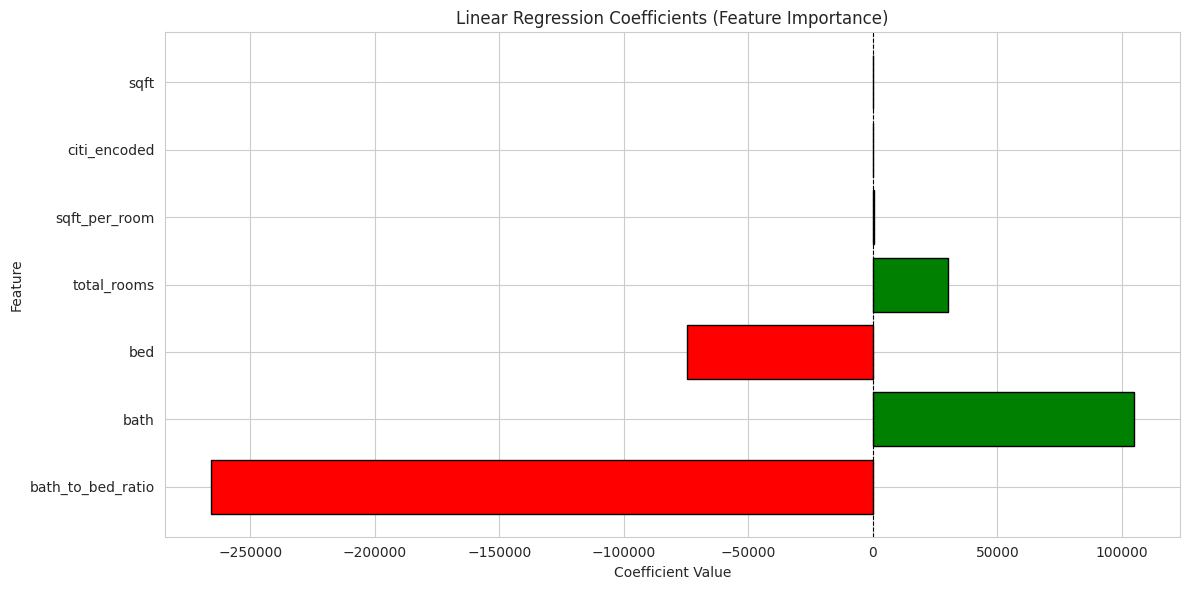

In [11]:
plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients (Feature Importance)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Model Evaluation

In [12]:
# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Calculate the metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # RMSE as a percentage of average price
    avg_price = y_true.mean()
    rmse_percent = (rmse / avg_price) * 100

    print(f"\n{dataset_name} Metrics: ")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"RMSE as % of avg price: {rmse_percent:.2f}%")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Average Price: ${avg_price:,.2f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'RMSE_Percent': rmse_percent}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

# Cross-validation
print("\nCross-Validation (5-Fold): ")
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
cv_rmse_scores = -cv_scores

print(f"CV RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: ${cv_rmse_scores.mean():,.2f}")
print(f"Std CV RMSE: ${cv_rmse_scores.std():,.2f}")


Training Set Metrics: 
Root Mean Squared Error (RMSE): $301,802.93
RMSE as % of avg price: 42.98%
Mean Absolute Error (MAE): $222,570.32
R² Score: 0.3530
Average Price: $702,129.95

Test Set Metrics: 
Root Mean Squared Error (RMSE): $309,313.21
RMSE as % of avg price: 43.74%
Mean Absolute Error (MAE): $228,128.65
R² Score: 0.3509
Average Price: $707,084.58

Cross-Validation (5-Fold): 
CV RMSE Scores: [297223.03599827 305082.41361655 302277.63530895 296565.16322064
 309613.19285069]
Mean CV RMSE: $302,152.29
Std CV RMSE: $4,894.49


# 6. Visualizations

# 6.1 Actual vs Predicted

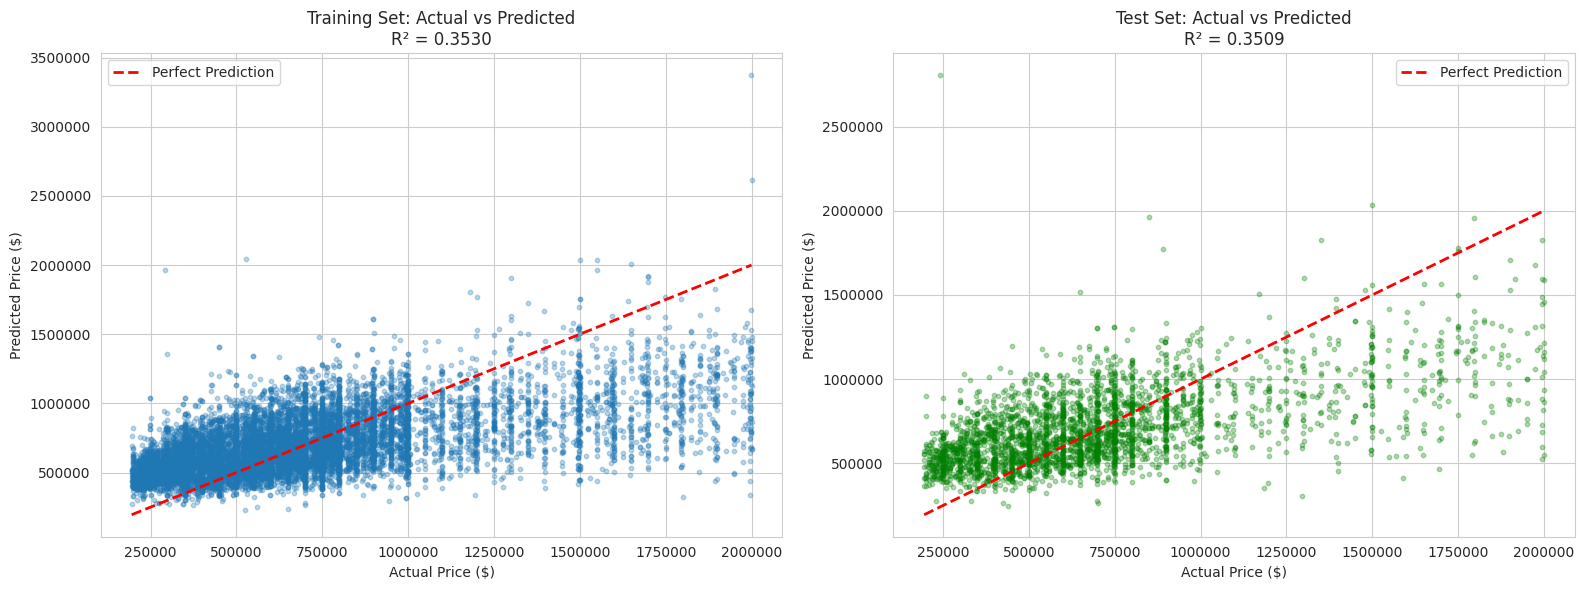

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["R2"]:.4f}')
axes[0].legend()
axes[0].ticklabel_format(style='plain')

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["R2"]:.4f}')
axes[1].legend()
axes[1].ticklabel_format(style='plain')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2 Residual plots

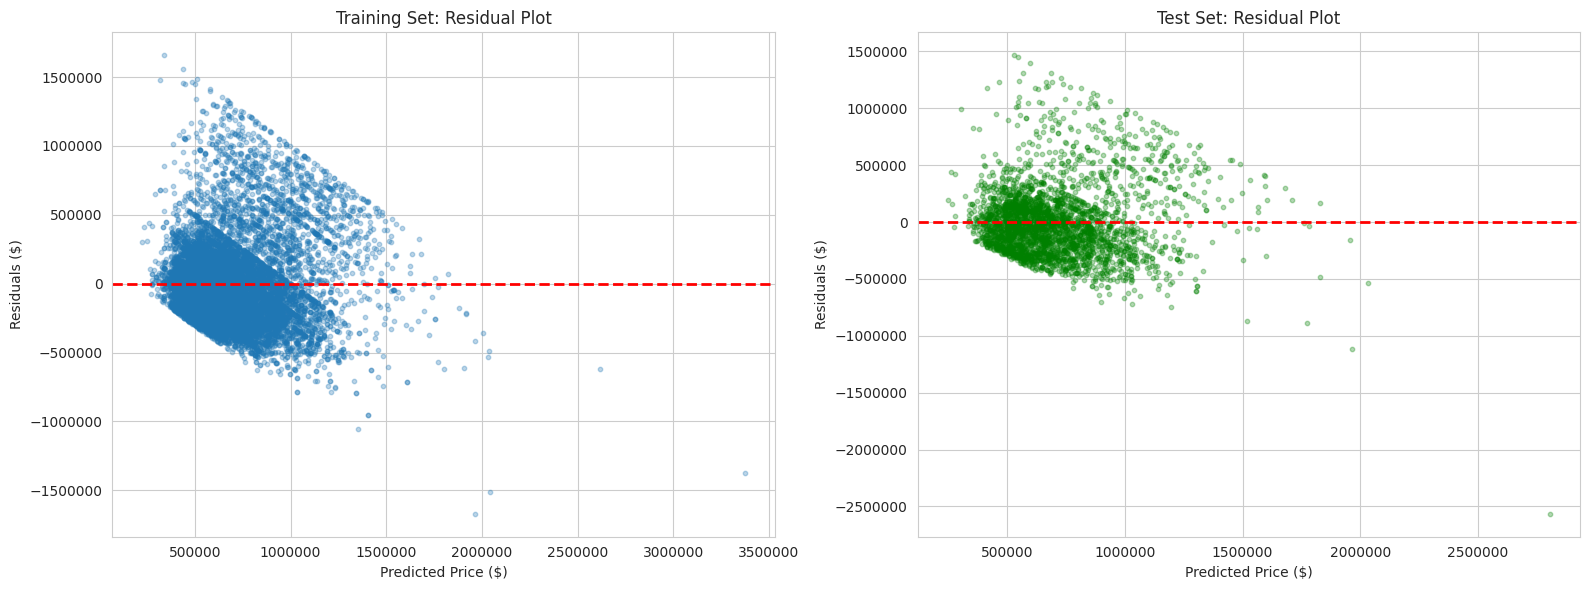

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training residuals
train_residuals = y_train - y_train_pred
axes[0].scatter(y_train_pred, train_residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Training Set: Residual Plot')
axes[0].ticklabel_format(style='plain')

# Test residuals
test_residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, test_residuals, alpha=0.3, s=10, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Test Set: Residual Plot')
axes[1].ticklabel_format(style='plain')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3 Residual distribution

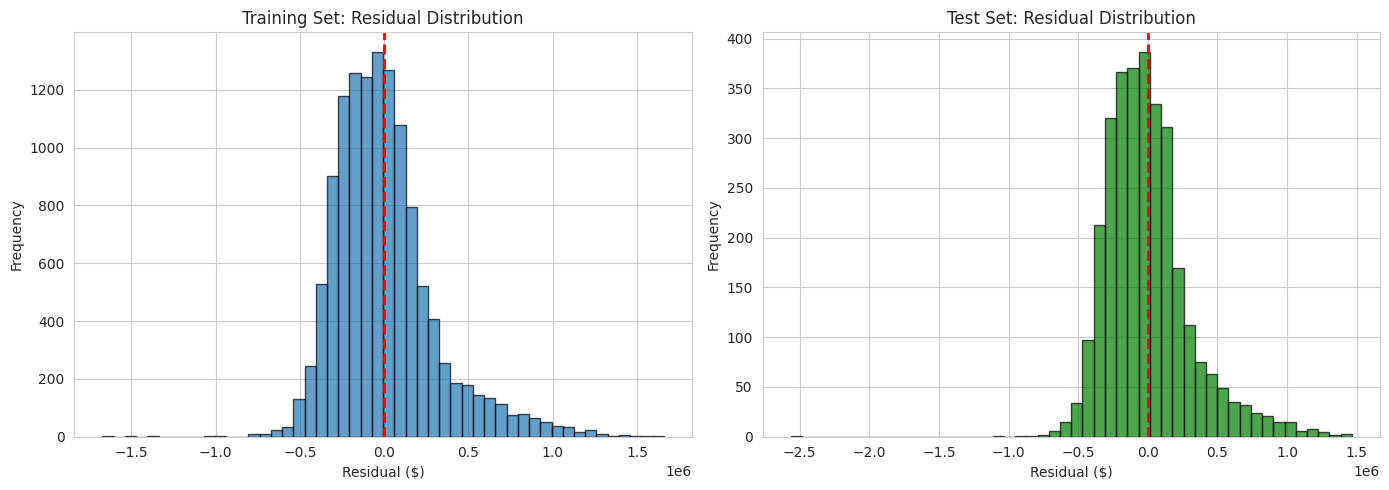

In [15]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(train_residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.title('Training Set: Residual Distribution')
plt.axvline(x=0, color='r', linestyle='--', lw=2)

plt.subplot(1, 2, 2)
plt.hist(test_residuals, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.title('Test Set: Residual Distribution')
plt.axvline(x=0, color='r', linestyle='--', lw=2)

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.4 Metrics comparison


Metrics Summary Table:
         Metric      Training          Test
       RMSE ($) 301802.931927 309313.212867
        MAE ($) 222570.315160 228128.647112
       R² Score      0.352972      0.350880
RMSE (% of avg)     42.983914     43.744868


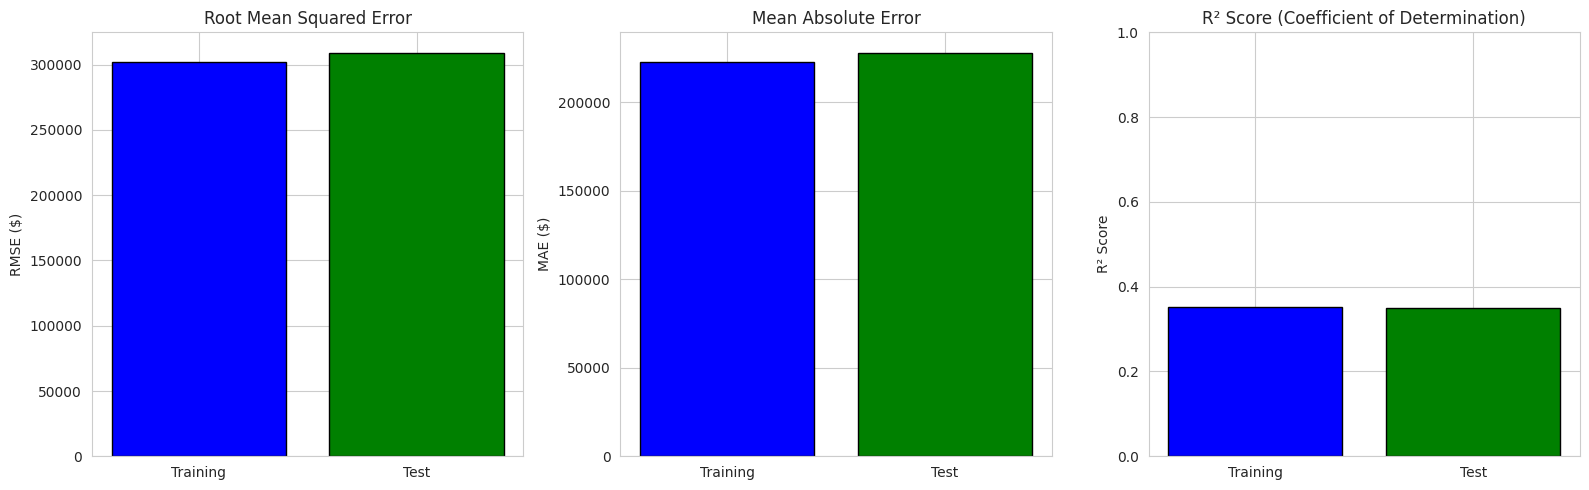

In [16]:
metrics_df = pd.DataFrame({
    'Metric': ['RMSE ($)', 'MAE ($)', 'R² Score', 'RMSE (% of avg)'],
    'Training': [train_metrics['RMSE'], train_metrics['MAE'],
                 train_metrics['R2'], train_metrics['RMSE_Percent']],
    'Test': [test_metrics['RMSE'], test_metrics['MAE'],
             test_metrics['R2'], test_metrics['RMSE_Percent']]
})

print("\nMetrics Summary Table:")
print(metrics_df.to_string(index=False))

# Visualize metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE comparison
axes[0].bar(['Training', 'Test'],
            [train_metrics['RMSE'], test_metrics['RMSE']],
            color=['blue', 'green'], edgecolor='black')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_title('Root Mean Squared Error')
axes[0].ticklabel_format(style='plain', axis='y')

# MAE comparison
axes[1].bar(['Training', 'Test'],
            [train_metrics['MAE'], test_metrics['MAE']],
            color=['blue', 'green'], edgecolor='black')
axes[1].set_ylabel('MAE ($)')
axes[1].set_title('Mean Absolute Error')
axes[1].ticklabel_format(style='plain', axis='y')

# R² comparison
axes[2].bar(['Training', 'Test'],
            [train_metrics['R2'], test_metrics['R2']],
            color=['blue', 'green'], edgecolor='black')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score (Coefficient of Determination)')
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Summary

In [17]:
print(f"""
MIDTERM CHECKPOINT SUMMARY:

Dataset:
- Total samples: {df.shape[0]}
- Training samples: {X_train.shape[0]}
- Test samples: {X_test.shape[0]}
- Features used: {len(feature_columns_for_model)}

Linear Regression Model Performance:
- Test RMSE: ${test_metrics['RMSE']:,.2f} ({test_metrics['RMSE_Percent']:.2f}% of average price)
- Test MAE: ${test_metrics['MAE']:,.2f}
- Test R²: {test_metrics['R2']:.4f}

Key Findings:
1. Square footage (sqft) shows the strongest correlation with price
2. City location (encoded) significantly impacts predictions
3. Engineered features (sqft_per_room, total_rooms) provide additional predictive power
4. Model achieves {'good' if test_metrics['RMSE_Percent'] < 15 else 'moderate'} accuracy with RMSE at {test_metrics['RMSE_Percent']:.1f}% of average price
""")



MIDTERM CHECKPOINT SUMMARY:

Dataset:
- Total samples: 15474
- Training samples: 12379
- Test samples: 3095
- Features used: 7

Linear Regression Model Performance:
- Test RMSE: $309,313.21 (43.74% of average price)
- Test MAE: $228,128.65
- Test R²: 0.3509

Key Findings:
1. Square footage (sqft) shows the strongest correlation with price
2. City location (encoded) significantly impacts predictions
3. Engineered features (sqft_per_room, total_rooms) provide additional predictive power
4. Model achieves moderate accuracy with RMSE at 43.7% of average price

